(a)

In [12]:
import numpy as np

rng = np.random.default_rng(1)  
X = rng.normal(size=100)
epsilon = rng.normal(size=100)

(b)

In [13]:
beta0 = 1
beta1 = 2
beta2 = -1
beta3 = 0.5

Y = beta0 + beta1*X + beta2*(X**2) + beta3*(X**3) + epsilon

(c)

In [14]:
import itertools
import numpy as np
import pandas as pd
import statsmodels.api as sm

# 建立資料表：X, X^2, ..., X^10
df = pd.DataFrame({'Y': Y})
for k in range(1, 11):
    df[f'X{k}'] = X**k

# 計算 Cp
def mallows_cp(model, sigma2_full):
    rss = sum(model.resid ** 2)
    p = model.df_model + 1
    n = model.nobs
    cp = rss/sigma2_full - (n - 2*p)
    return cp

# 先跑 full model 估計 sigma^2
X_full = sm.add_constant(df[[f'X{k}' for k in range(1, 11)]])
full_model = sm.OLS(df['Y'], X_full).fit()
sigma2_full = sum(full_model.resid**2) / (len(df) - full_model.df_model - 1)

# Forward Stepwise Selection
remaining = [f'X{k}' for k in range(1, 11)]
selected = []
results = []

while len(remaining) > 0:
    cp_list = []
    for predictor in remaining:
        predictors = selected + [predictor]
        X_temp = sm.add_constant(df[predictors])
        model_temp = sm.OLS(df['Y'], X_temp).fit()
        cp_list.append((predictor, mallows_cp(model_temp, sigma2_full), model_temp))
    
    # 選 Cp 最小的 predictor
    chosen, cp_value, chosen_model = min(cp_list, key=lambda x: x[1])
    selected.append(chosen)
    remaining.remove(chosen)
    
    results.append((selected.copy(), cp_value, chosen_model))

# 找到整個 forward-selection 過程中 Cp 最小的
best_model = min(results, key=lambda x: x[1])
best_predictors = best_model[0]
best_cp = best_model[1]
best_fit = best_model[2]

print("最佳模型（Cp 最小）使用的變數：", best_predictors)
print("Cp =", best_cp)
print(best_fit.summary())


最佳模型（Cp 最小）使用的變數： ['X3', 'X1', 'X2', 'X10']
Cp = 2.9076014725546173
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.935
Method:                 Least Squares   F-statistic:                     358.2
Date:                Sat, 22 Nov 2025   Prob (F-statistic):           2.27e-56
Time:                        18:20:00   Log-Likelihood:                -135.03
No. Observations:                 100   AIC:                             280.1
Df Residuals:                      95   BIC:                             293.1
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------

(d)

In [15]:
import statsmodels.api as sm

# 所有變數一開始都在模型裡
current_predictors = [f'X{k}' for k in range(1, 11)]
results_backward = []

def fit_model(preds):
    X_temp = sm.add_constant(df[preds])
    return sm.OLS(df['Y'], X_temp).fit()

def mallows_cp(model, sigma2_full):
    rss = sum(model.resid ** 2)
    p = model.df_model + 1
    n = model.nobs
    cp = rss/sigma2_full - (n - 2*p)
    return cp

# 初始 full model
current_model = fit_model(current_predictors)
current_cp = mallows_cp(current_model, sigma2_full)

while len(current_predictors) > 1:
    cp_list = []
    for predictor in current_predictors:
        trial_predictors = [p for p in current_predictors if p != predictor]
        model_temp = fit_model(trial_predictors)
        cp_list.append((predictor, mallows_cp(model_temp, sigma2_full), model_temp))
    
    # 找出移除哪一個 predictor 會讓 Cp 最小
    drop_var, cp_value, model_new = min(cp_list, key=lambda x: x[1])

    if cp_value < current_cp:   # Cp 變更好 → 接受移除
        current_predictors.remove(drop_var)
        current_cp = cp_value
        current_model = model_new
        results_backward.append((current_predictors.copy(), current_cp))
    else:
        break

print("Backward Stepwise 選出的最終模型：", current_predictors)
print("Cp =", current_cp)
print(current_model.summary())


Backward Stepwise 選出的最終模型： ['X1', 'X2', 'X6', 'X7', 'X8']
Cp = 4.791369828910163
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.935
Method:                 Least Squares   F-statistic:                     284.0
Date:                Sat, 22 Nov 2025   Prob (F-statistic):           4.32e-55
Time:                        18:20:03   Log-Likelihood:                -134.97
No. Observations:                 100   AIC:                             281.9
Df Residuals:                      94   BIC:                             297.6
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------

(e)

=== Best lambda (alpha) ===
0.029673024081888696

=== Coefficients ===
X3     1.581079
X1    -1.379091
X2     1.608718
X10   -0.000000
X4     0.000000
X5     0.000000
X8    -0.000000
X9     0.000000
X7    -0.000000
X6     0.404975
dtype: float64

=== Selected variables (non-zero) ===
['X3', 'X1', 'X2', 'X6']


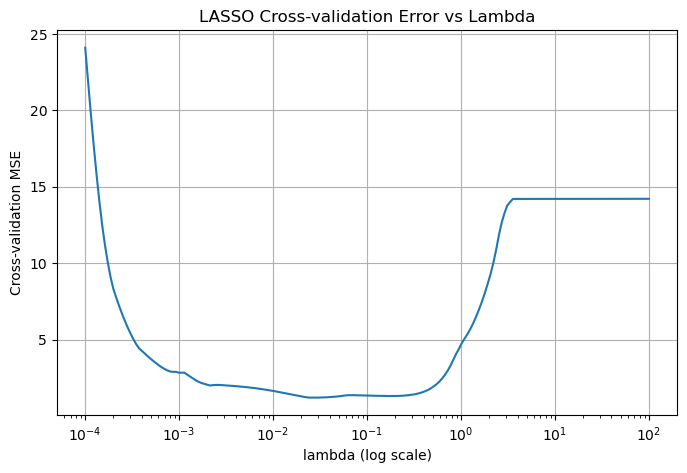

In [18]:
import matplotlib.pyplot as plt

coef = pd.Series(lasso.coef_, index=predictors)

print("=== Best lambda (alpha) ===")
print(lasso.alpha_)

print("\n=== Coefficients ===")
print(coef)

print("\n=== Selected variables (non-zero) ===")
print(coef[coef != 0].index.tolist())

plt.figure(figsize=(8,5))
plt.plot(lasso.alphas_, lasso.mse_path_.mean(axis=1))
plt.xscale("log")
plt.xlabel("lambda (log scale)")
plt.ylabel("Cross-validation MSE")
plt.title("LASSO Cross-validation Error vs Lambda")
plt.grid(True)
plt.show()

(f)

In [7]:
beta0 = 1
beta7 = 3

Y2 = beta0 + beta7 * (X**7) + epsilon
df['Y2'] = Y2

In [8]:
import statsmodels.api as sm

df2 = df.copy()

# 重新建立 X^1 ... X^10
for k in range(1, 11):
    df2[f'X{k}'] = X**k

# full σ² for Cp（用 Y2）
X_full = sm.add_constant(df2[[f'X{k}' for k in range(1, 11)]])
full_model = sm.OLS(df2['Y2'], X_full).fit()
sigma2_full = sum(full_model.resid**2) / (len(df2) - full_model.df_model - 1)

def mallows_cp(model, sigma2_full):
    rss = sum(model.resid ** 2)
    p = model.df_model + 1
    n = model.nobs
    cp = rss/sigma2_full - (n - 2*p)
    return cp

remaining = [f'X{k}' for k in range(1, 11)]
selected = []
results = []

while remaining:
    cp_list = []
    for pred in remaining:
        preds = selected + [pred]
        model_temp = sm.OLS(df2['Y2'], sm.add_constant(df2[preds])).fit()
        cp_list.append((pred, mallows_cp(model_temp, sigma2_full), model_temp))
    
    chosen, cp_val, chosen_model = min(cp_list, key=lambda x: x[1])
    selected.append(chosen)
    remaining.remove(chosen)
    results.append((selected.copy(), cp_val, chosen_model))

# best model
best_fwd_model = min(results, key=lambda x: x[1])
best_fwd_predictors = best_fwd_model[0]
best_fwd_predictors

['X7', 'X9', 'X4']

In [9]:
from sklearn.linear_model import LassoCV
import numpy as np

Xmat = df2[[f'X{k}' for k in range(1, 11)]].values
Yvec = df2['Y2'].values

lasso2 = LassoCV(cv=10, random_state=1).fit(Xmat, Yvec)

print("最佳 λ =", lasso2.alpha_)
for name, coef in zip([f'X{k}' for k in range(1, 11)], lasso2.coef_):
    print(name, coef)

最佳 λ = 8012.3431786262645
X1 0.0
X2 -0.0
X3 0.0
X4 -0.0
X5 0.0
X6 -0.0
X7 0.0
X8 -0.0
X9 0.4071194450690136
X10 -0.0
